<a href="https://colab.research.google.com/github/njones61/xslope/blob/main/docs/lim_eq/xslope_lem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XSLOPE - Limit Equilibrium Method

This notebook illustrates how to use xslope to solve basic slope stability problems using the limit equilibrium method.

## Install xslope and import functions

In [1]:
# Install the xslope package
# - Basic install (limit equilibrium only): pip install xslope
# - Full install (with FEM features): pip install xslope[fem]

%%capture
!pip install xslope

In [2]:
# Import functions

import xslope as xslope

from xslope.global_config import non_circ
from xslope.slice import generate_slices
from xslope.fileio import load_slope_data, load_data_from_pickle
from xslope.plot import plot_circular_search_results, plot_inputs, plot_solution, plot_noncircular_search_results
from xslope.solve import solve_selected, solve_all
from xslope.search import circular_search, noncircular_search

## Upload Excel Template

In [6]:
# Upload excel input template for selected problem

from google.colab import files
upload = files.upload()
file_name = list(upload.keys())[0]

Saving input_template_griffiths1_6 copy.xlsx to input_template_griffiths1_6 copy.xlsx


## Load slope data

In [9]:
slope_data = load_slope_data(file_name)



## Plot inputs

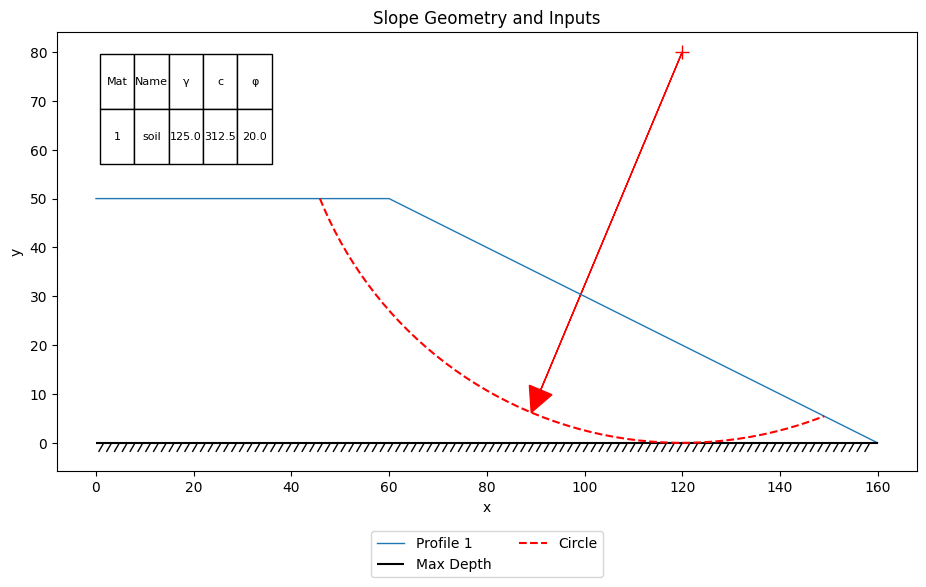

In [10]:
plot_inputs(slope_data)

In [23]:
# @title Select Options {"run":"auto"}
method = "spencer" # @param ["oms","bishop","janbu","corps_engineers","lowe_karafiath","spencer"]
num_slices = 20 # @param {"type":"integer"}
auto_search = True # @param {"type":"boolean"}
surface_type = "circular" # @param ["circular","non_circular"]



## Find and plot solution

[🔁 iteration 1] center=(132.00, 92.00), FS=1.4032, grid=13.8000
[🔁 iteration 2] center=(145.80, 105.80), FS=1.3994, grid=13.8000
[🔁 iteration 3] center=(145.80, 119.60), FS=1.3762, grid=13.8000
[🔁 iteration 4] center=(145.80, 119.60), FS=1.3762, grid=6.9000
[🔁 iteration 5] center=(145.80, 119.60), FS=1.3762, grid=3.4500
[🔁 iteration 6] center=(145.80, 123.05), FS=1.3758, grid=3.4500
[🔁 iteration 7] center=(145.80, 123.05), FS=1.3758, grid=1.7250
[🔁 iteration 8] center=(145.80, 121.33), FS=1.3757, grid=1.7250
[✅ converged] Iter=8, FS=1.3757 at (x=145.80, y=121.33, depth=0.00), elapsed time=5.24 seconds


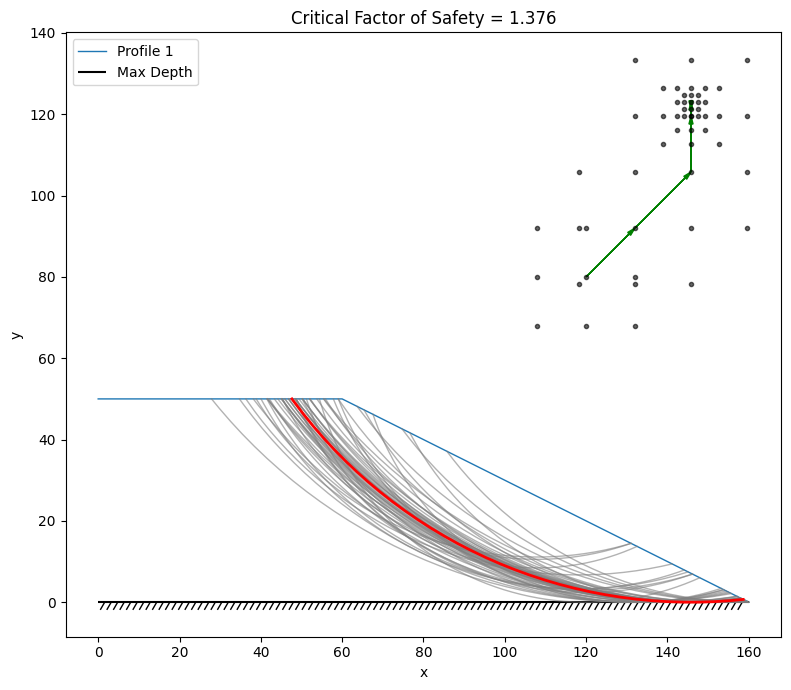

In [24]:
if surface_type == "circular":
  circle = slope_data['circles'][0] if slope_data['circular'] else None
  success, result = generate_slices(slope_data, circle=circle, non_circ=None, num_slices=num_slices)
else:
  non_circ = slope_data['non_circ'] if slope_data['non_circ'] else None
  success, result = generate_slices(slope_data, circle=None, non_circ=non_circ, num_slices=num_slices)

if success:
    slice_df, failure_surface = result
else:
    print(result)
    exit()

if auto_search:
  if surface_type == "circular":
    fs_cache, converged, search_path = circular_search(slope_data, method, diagnostic=False)
    plot_circular_search_results(slope_data, fs_cache, search_path)
  else:
    fs_cache, converged, search_path = noncircular_search(slope_data, method, diagnostic=False)
    plot_noncircular_search_results(slope_data, fs_cache, search_path)
else:
  results = solve_selected(method, slice_df, rapid=False)
  plot_solution(slope_data, slice_df, failure_surface, results)


## Automated search for critical surface

[🔁 iteration 1] center=(132.00, 92.00), FS=1.4032, grid=13.8000
[🔁 iteration 2] center=(145.80, 105.80), FS=1.3994, grid=13.8000
[🔁 iteration 3] center=(145.80, 119.60), FS=1.3762, grid=13.8000
[🔁 iteration 4] center=(145.80, 119.60), FS=1.3762, grid=6.9000
[🔁 iteration 5] center=(145.80, 119.60), FS=1.3762, grid=3.4500
[🔁 iteration 6] center=(145.80, 123.05), FS=1.3758, grid=3.4500
[🔁 iteration 7] center=(145.80, 123.05), FS=1.3758, grid=1.7250
[🔁 iteration 8] center=(145.80, 121.33), FS=1.3757, grid=1.7250
[✅ converged] Iter=8, FS=1.3757 at (x=145.80, y=121.33, depth=0.00), elapsed time=6.95 seconds


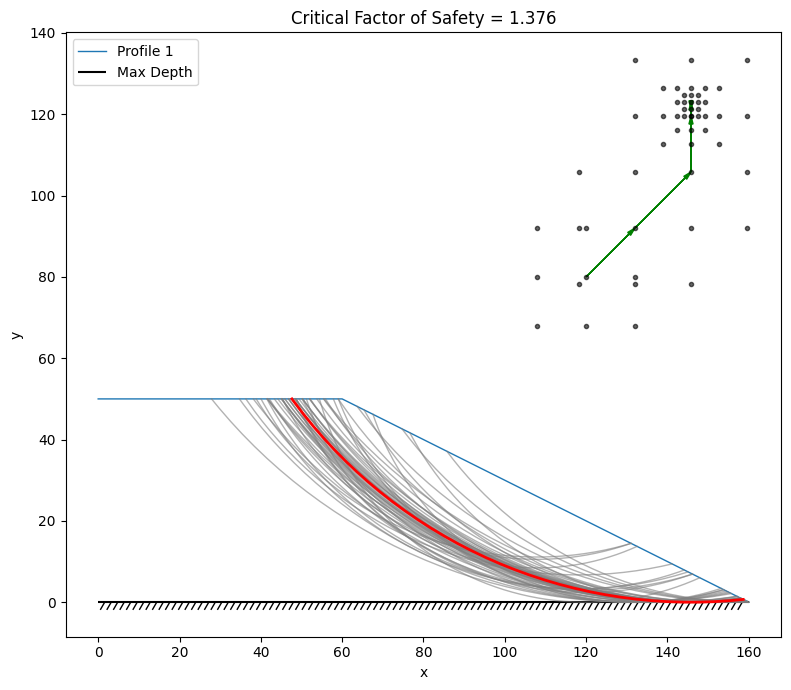